In [90]:
!pip install git+https://github.com/drapado/d2l-wur.git
!pip install scipy --quiet
!pip install torchmetrics --quiet
!pip install torch-summary --quiet

  Cloning https://github.com/drapado/d2l-wur.git to /tmp/pip-req-build-ri5tn3oj
  Running command git clone --filter=blob:none --quiet https://github.com/drapado/d2l-wur.git /tmp/pip-req-build-ri5tn3oj
  Resolved https://github.com/drapado/d2l-wur.git to commit fe9e2db3f28092dc60ea8d317e72dd708f57cfb5
  Preparing metadata (setup.py) ... done


In [91]:
%matplotlib inline
from d2l import torch as d2l
import torch
import torchvision
from torchvision.transforms import ToPILImage
from torch import nn
from torch.nn import functional as F
from PIL import ImageFile, Image
import matplotlib.pyplot as plt
from object_detection_utils import ResizeWithBBox, plot_bbox, plot_grid, box_xyxy_to_cxcywh, box_xywh_to_xyxy
import random
import cv2

# Download the dataset
First, let's download the dataset. It consists of images of plant, bounding box annotations, and leaf counts annotations.

In [92]:
!git clone https://git.wur.nl/abe-datasets/education/fruit-detection-challenge.git

fatal: destination path 'fruit-detection-challenge' already exists and is not an empty directory.


## The COCO dataset format

The labels for this detection dataset are stored using the COCO JSON format. COCO JSON is a data format used for object detection, segmentation, and keypoint annotation in images. It includes metadata like image paths, annotations, categories, and licenses, typically structured into keys such as "images," "annotations," "categories," and more.

Example structure:
```json
{
  "images": [
    {
      "id": 1,
      "width": 640,
      "height": 480,
      "file_name": "image1.jpg",
      "license": 1,
      "date_captured": "2023-10-01"
    }
  ],
  "annotations": [
    {
      "id": 1,
      "image_id": 1,
      "category_id": 1,
      "bbox": [50, 70, 80, 60],
      "area": 4800,
      "segmentation": [[121.39,215.89,...]],
      "iscrowd": 0
    }
  ],
  "categories": [
    {
      "id": 1,
      "name": "cat",
      "supercategory": "animal"
    },
    {
      "id": 2,
      "name": "dog",
      "supercategory": "animal"
    }
  ]
}
```

Let's open the `train.json` file and explore it:

In [93]:
import json

json_path = "fruit-detection-challenge/detection/annotations/train.json"

with open(json_path, 'r') as f:
    data = json.load(f)

print(data.keys())
print(f"Number of images: {len(data['images'])}")
print(f"Number of annotations: {len(data['annotations'])}")
print(f"Number of categories: {len(data['categories'])}")
print(f"Categories: {data['categories']}")
print(f"Example image: {data['images'][0]}")
print(f"Example annotation: {data['annotations'][0]}")

dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])
Number of images: 218
Number of annotations: 1603
Number of categories: 4
Categories: [{'id': 1, 'name': 'apple', 'supercategory': ''}, {'id': 2, 'name': 'banana', 'supercategory': ''}, {'id': 3, 'name': 'orange', 'supercategory': ''}, {'id': 4, 'name': 'pear', 'supercategory': ''}]
Example image: {'id': 1, 'file_name': 'scene 1_color_001.png', 'width': 1280, 'height': 720, 'license': 0, 'flickr_url': '', 'coco_url': '', 'date_captured': ''}
Example annotation: {'id': 1, 'image_id': 1, 'category_id': 2, 'bbox': [463.0, 197.0, 294.0, 282.0], 'area': 25736.5, 'iscrowd': 0, 'ignore': 0, 'segmentation': [[702.0, 200.0, 691.0, 197.0, 681.0, 198.0, 673.0, 206.0, 666.0, 223.0, 667.0, 233.0, 672.0, 240.0, 675.0, 242.0, 686.0, 243.0, 696.0, 254.0, 703.0, 268.0, 706.0, 280.0, 706.0, 288.0, 704.0, 293.0, 699.0, 300.0, 681.0, 338.0, 669.0, 354.0, 657.0, 365.0, 635.0, 380.0, 596.0, 398.0, 553.0, 410.0, 522.0, 416.0, 494.0, 429.0

In [94]:
import os
import random
from PIL import Image
from object_detection_utils import plot_bbox

json_path = "fruit-detection-challenge/detection/annotations/train.json"
image_folder = "fruit-detection-challenge/detection/train/"

with open(json_path, 'r') as f:
    data = json.load(f)

images = data['images']
random_image_info = random.choice(images) # Select a random image from the images list in JSON
image_id = random_image_info['id']
image_path = os.path.join(image_folder, random_image_info['file_name'])
print(f"Selected image: {image_path}")

img = Image.open(image_path)

boxes = []
labels = []

for annotation in data['annotations']:
    if annotation['image_id'] == image_id:
        bbox = annotation['bbox']
        x, y, w, h = bbox  # COCO box format is [x, y, width, height]
        center_x = x + w / 2.0
        center_y = y + h / 2.0
        boxes.append((center_x, center_y, w, h))
        labels.append(annotation['category_id'] - 1) # COCO category IDs start from 1, so we subtract 1 to make it zero-indexed

print(f"Boxes: {boxes}")
print(f"Labels: {labels}")

img_with_bboxes = plot_bbox(img.copy(), boxes, labels)
img_with_bboxes.show()

Selected image: fruit-detection-challenge/detection/train/scene 5_color_038.png
Boxes: [(701.5, 226.0, 175.0, 176.0), (563.5, 332.0, 185.0, 184.0), (418.5, 489.0, 217.0, 188.0), (1075.5, 254.0, 241.0, 214.0), (833.5, 388.5, 159.0, 281.0), (962.0, 524.0, 204.0, 194.0), (661.5, 557.5, 239.0, 309.0), (810.5, 650.5, 315.0, 137.0)]
Labels: [2, 2, 2, 2, 3, 3, 3, 3]


Let's explore the labels for the two-step method.

In [95]:
json_path = "fruit-detection-challenge/detection/annotations/train_one_class.json"

with open(json_path, 'r') as f:
    data = json.load(f)

print(data.keys())
print(f"Number of images: {len(data['images'])}")
print(f"Number of annotations: {len(data['annotations'])}")
print(f"Number of categories: {len(data['categories'])}")
print(f"Categories: {data['categories']}")
print(f"Example image: {data['images'][0]}")
print(f"Example annotation: {data['annotations'][0]}")

dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])
Number of images: 218
Number of annotations: 1603
Number of categories: 1
Categories: [{'id': 1, 'name': 'fruit', 'supercategory': ''}]
Example image: {'id': 1, 'file_name': 'scene 1_color_001.png', 'width': 1280, 'height': 720, 'license': 0, 'flickr_url': '', 'coco_url': '', 'date_captured': ''}
Example annotation: {'id': 1, 'image_id': 1, 'category_id': 1, 'bbox': [463.0, 197.0, 294.0, 282.0], 'area': 25736.5, 'iscrowd': 0, 'ignore': 0, 'segmentation': [[702.0, 200.0, 691.0, 197.0, 681.0, 198.0, 673.0, 206.0, 666.0, 223.0, 667.0, 233.0, 672.0, 240.0, 675.0, 242.0, 686.0, 243.0, 696.0, 254.0, 703.0, 268.0, 706.0, 280.0, 706.0, 288.0, 704.0, 293.0, 699.0, 300.0, 681.0, 338.0, 669.0, 354.0, 657.0, 365.0, 635.0, 380.0, 596.0, 398.0, 553.0, 410.0, 522.0, 416.0, 494.0, 429.0, 487.0, 431.0, 477.0, 431.0, 468.0, 434.0, 465.0, 439.0, 463.0, 454.0, 467.0, 459.0, 491.0, 471.0, 506.0, 476.0, 522.0, 479.0, 562.0, 478.0, 595.0,

In [96]:
json_path = "fruit-detection-challenge/detection/annotations/train_one_class.json"
image_folder = "fruit-detection-challenge/detection/train/"

with open(json_path, 'r') as f:
    data = json.load(f)

images = data['images']
random_image_info = random.choice(images) # Select a random image from the images list in JSON
image_id = random_image_info['id']
image_path = os.path.join(image_folder, random_image_info['file_name'])
print(f"Selected image: {image_path}")

img = Image.open(image_path)

boxes = []
labels = []

for annotation in data['annotations']:
    if annotation['image_id'] == image_id:
        bbox = annotation['bbox']
        x, y, w, h = bbox  # COCO box format is [x, y, width, height]
        center_x = x + w / 2.0
        center_y = y + h / 2.0
        boxes.append((center_x, center_y, w, h))
        labels.append(annotation['category_id'] - 1) # COCO category IDs start from 1, so we subtract 1 to make it zero-indexed

print(f"Boxes: {boxes}")
print(f"Labels: {labels}")

img_with_bboxes = plot_bbox(img.copy(), boxes, labels)
img_with_bboxes.show()

Selected image: fruit-detection-challenge/detection/train/scene 5_color_055.png
Boxes: [(559.5, 489.0, 205.0, 166.0), (545.0, 216.5, 210.0, 187.0), (576.0, 270.0, 422.0, 294.0), (487.0, 101.5, 444.0, 203.0), (660.0, 241.5, 82.0, 117.0)]
Labels: [0, 0, 0, 0, 0]


# The `Dataset` class from COCO json data
Now, let's create a dataset customized to our data.
We will call it `FruitDetectionDataset`. You need to define three methods (as you should aready know): the constructor `__init__`, `__get_item__` and `__len__`.

In [97]:
import json
import os
import torch
# TODO: add needed imports

class FruitDetectionDataset(torch.utils.data.Dataset):
    def __init__(self, json_path, img_folder, img_size, transforms=None):
        """
        Constructor of the FruitDetectionDataset
        :param json_path: Path to the COCO JSON file
        :param img_folder: Folder containing the images
        :param img_size: Size to resize the images
        :param transforms: List of transformations to be applied to the data
        """
        self.img_folder = img_folder
        self.transforms = transforms
        self.resize = ResizeWithBBox(img_size)

        with open(json_path, 'r') as f:
            coco_data = json.load(f)

        # TODO: Extract image info and annotations
        self.images = coco_data['images']
        self.annotations = coco_data['annotations']
        self.categories = coco_data['categories']

        # Mapping from category ID to category index
        # This creates a zero-based index
        self.category_id_to_index = {category['id']: idx for idx, category in enumerate(self.categories)}

        # Mapping from image ID to annotations
        self.img_id_to_annotations = {}
        for annotation in self.annotations:
            img_id = annotation['image_id']
            if img_id not in self.img_id_to_annotations:
                self.img_id_to_annotations[img_id] = []
            self.img_id_to_annotations[img_id].append(annotation)

        self.max_boxes = max(len(v) for v in self.img_id_to_annotations.values())

        # Create a list of image paths
        self.img_files = [os.path.join(img_folder, img['file_name']) for img in self.images]

    def __getitem__(self, idx):
        # TODO Get image path and annotations
        img_path = self.img_files[idx]
        img_id = self.images[idx]['id']
        annotations = self.img_id_to_annotations.get(img_id, [])

        # Load image
        img = Image.open(img_path).convert("RGB") # TODO PIL Image format

        # Extract bounding boxes and labels
        bboxes = []
        labels = []
        for annotation in annotations:
            x, y, width, height = annotation['bbox']
            bboxes.append([x, y, width, height])
            category_id = annotation['category_id']
            labels.append(self.category_id_to_index[category_id])

        bboxes = torch.tensor(bboxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)

        if len(bboxes.shape) == 1:
            bboxes = bboxes.unsqueeze(0)

        # TODO: Resize image and boxes
        img, bboxes = self.resize(img, bboxes)
        bboxes = torch.tensor(bboxes, dtype=torch.float32)

        # TODO: Convert boxes to center x, center y, width, height format
        bboxes = box_xyxy_to_cxcywh(box_xywh_to_xyxy(bboxes))

        # Apply other transforms
        if self.transforms:
            img = self.transforms(img)

        # TODO Add illegal boxes if needed
        illegal_needed = self.max_boxes - len(bboxes)
        illegal_labels = torch.ones((illegal_needed,), dtype=torch.int64) * -1
        illegal_boxes = torch.zeros((illegal_needed, 4), dtype=torch.float32)

        return img, {
            "labels": torch.cat((labels, illegal_labels)),
            "boxes": torch.cat((bboxes, illegal_boxes), axis=0),
        }

    def __len__(self): # TODO
        return len(self.images)


This dataset should allow you to develop your object detection algorithm for both methods (two-stage with one class and single stage with 4 classes)

# Two-step approach
The two-step approach consists of a generic fruit detector plus a fruit classifier. You can use `FruitDetectionDataset` to train your generic fruit detector. However, we need a different dataset for your classifier. To help you, we've already cropped all the fruits from the training and validation images and store them in a folder. Let's explore it.

In [98]:
import torchvision


data_dir = "fruit-detection-challenge/classification"

train_imgs = torchvision.datasets.ImageFolder(
    os.path.join(data_dir, 'train'))
val_imgs = torchvision.datasets.ImageFolder(
    os.path.join(data_dir, 'val'))

In [99]:
train_imgs.classes

['apple', 'banana', 'orange', 'pear']

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

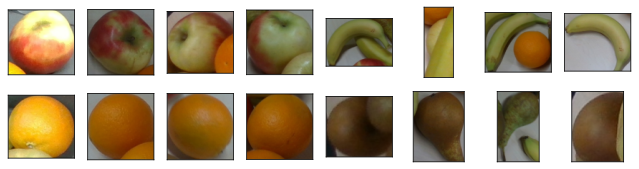

In [100]:
from d2l import torch as d2l

class_names = train_imgs.classes
images = []

for i in range(len(train_imgs.classes)):
    class_idx = i % len(class_names)
    class_name = class_names[class_idx]
    class_images = [img for img, label in train_imgs if label == class_idx]
    for i in range(4): # Select 4 random images from the class
        images.append(random.choice(class_images))

d2l.show_images(images, 2, 8, scale=1.4)


## Step 1: Fruit classifier
(Based on the fine_tuning_pytorch practical)

In [101]:
import os
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader

data_dir = "fruit-detection-challenge/classification"
batch_size = 32

train_augs = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

test_augs = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_imgs = torchvision.datasets.ImageFolder(
    os.path.join(data_dir, "train"),
    transform=train_augs
)

test_imgs = torchvision.datasets.ImageFolder(
    os.path.join(data_dir, "val"),
    transform=test_augs
)

train_loader = DataLoader(train_imgs, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_imgs, batch_size=batch_size, shuffle=False)

print("Classes:", train_imgs.classes)
print("Number of training images:", len(train_imgs))
print("Number of validation images:", len(test_imgs))

Classes: ['apple', 'banana', 'orange', 'pear']
Number of training images: 1603
Number of validation images: 72


### Classifier model (fine-tuning)
(Based on fine_tuning_pytorch practical)

In [102]:
import torch.nn as nn
import torchvision

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(train_imgs.classes)

model = torchvision.models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)
model_cls = model

loss = nn.CrossEntropyLoss()
trainer = torch.optim.SGD(model.parameters(), lr=0.01)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


### Train classifier

loss 0.001, train acc 0.992, test acc 0.986
345.5 examples/sec on [device(type='cuda', index=0)]


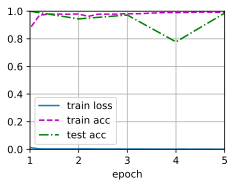

In [103]:
from d2l import torch as d2l

num_epochs = 5
devices = [d2l.try_gpu()]

d2l.train_ch13(
    model_cls,
    train_loader,
    test_loader,
    loss,
    trainer,
    num_epochs,
    devices
)

In [104]:
torch.save(model.state_dict(), "resnet18_finetuned.pth")

## Fruit detector
(based on week2_02_localization practical)

In [105]:
from torch.utils.data import DataLoader

train_dataset = FruitDetectionDataset(
    json_path="fruit-detection-challenge/detection/annotations/train_one_class.json",
    img_folder="fruit-detection-challenge/detection/train",
    img_size=(224, 224),
    transforms=transforms.ToTensor()
)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

print(len(train_dataset))

218


### Define the fruit detector model
(using predictionhead and objectdetectormultiscale from object_det_day2 practical)

In [106]:
import torch
import torch.nn as nn
import torchvision.models as models

class PredictionHead(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(PredictionHead, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // 2, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(in_channels // 2),
            nn.LeakyReLU(negative_slope=0.1),
            nn.Conv2d(in_channels // 2, in_channels // 4, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(in_channels // 4),
            nn.LeakyReLU(negative_slope=0.1),
            nn.Conv2d(in_channels // 4, in_channels // 4, kernel_size=1, stride=1, padding=0),
            nn.BatchNorm2d(in_channels // 4),
            nn.LeakyReLU(negative_slope=0.1),
        )

        self.box_predictor = nn.Sequential(
            nn.Conv2d(in_channels // 4, in_channels // 4, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(in_channels // 4),
            nn.LeakyReLU(negative_slope=0.1),
            nn.Conv2d(in_channels // 4, 4, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid(),
        )

        self.classifier = nn.Sequential(
            nn.Conv2d(in_channels // 4, in_channels // 4, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(in_channels // 4),
            nn.LeakyReLU(negative_slope=0.1),
            nn.Conv2d(in_channels // 4, num_classes, kernel_size=3, stride=1, padding=1),
        )

        self.objectness_predictor = nn.Sequential(
            nn.Conv2d(in_channels // 4, in_channels // 4, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(in_channels // 4),
            nn.LeakyReLU(negative_slope=0.1),
            nn.Conv2d(in_channels // 4, 1, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = self.conv_layers(x)
        cls_logits = self.classifier(x)
        bbox_pred = self.box_predictor(x)
        objectness_pred = self.objectness_predictor(x)

        grid_size = x.shape[-1]
        grid_y, grid_x = torch.meshgrid(
            torch.arange(grid_size, device=x.device),
            torch.arange(grid_size, device=x.device),
            indexing="ij",
        )
        cx = (bbox_pred[:, 0, :, :] + grid_x) / grid_size
        cy = (bbox_pred[:, 1, :, :] + grid_y) / grid_size
        w = bbox_pred[:, 2, :, :]
        h = bbox_pred[:, 3, :, :]

        bbox_pred = torch.stack([cx, cy, w, h], dim=1)
        return cls_logits, bbox_pred, objectness_pred


class ObjectDetectorMultiScale(nn.Module):
    def __init__(self, n_classes, pretrained=True):
        super(ObjectDetectorMultiScale, self).__init__()

        self.n_classes = n_classes

        backbone = models.resnet18(pretrained=pretrained)
        self.backbone = nn.Sequential(*list(backbone.children())[:-3])
        self.block_1 = nn.Sequential(*list(backbone.children())[-3])

        self.prediction_head = PredictionHead(512, self.n_classes)
        self.prediction_head_2 = PredictionHead(256, self.n_classes)

    def forward(self, x):
        features = self.backbone(x)
        y_ = self.block_1(features)

        cls_logits, bbox_pred, objectness_pred = self.prediction_head(y_)
        cls_preds = cls_logits.flatten(2, 3).permute(0, 2, 1)
        box_preds = bbox_pred.flatten(2, 3).permute(0, 2, 1)
        obj_preds = objectness_pred.flatten(2, 3).permute(0, 2, 1)

        cls_logits2, bbox_pred2, objectness_pred2 = self.prediction_head_2(features)
        cls_preds2 = cls_logits2.flatten(2, 3).permute(0, 2, 1)
        box_preds2 = bbox_pred2.flatten(2, 3).permute(0, 2, 1)
        obj_preds2 = objectness_pred2.flatten(2, 3).permute(0, 2, 1)

        pred_logits = torch.cat([cls_preds, cls_preds2], dim=1)
        pred_boxes = torch.cat([box_preds, box_preds2], dim=1)
        pred_objectness = torch.cat([obj_preds, obj_preds2], dim=1)

        return {
            "pred_logits": pred_logits,
            "pred_boxes": pred_boxes,
            "pred_objectness": pred_objectness,
        }

model_det = ObjectDetectorMultiScale(n_classes=1, pretrained=True).to(device)

### Create training and validation loaders for detector

In [107]:
train_dataset = FruitDetectionDataset(
    json_path="fruit-detection-challenge/detection/annotations/train_one_class.json",
    img_folder="fruit-detection-challenge/detection/train",
    img_size=(224, 224),
    transforms=transforms.ToTensor()
)

val_dataset = FruitDetectionDataset(
    json_path="fruit-detection-challenge/detection/annotations/val_one_class.json",
    img_folder="fruit-detection-challenge/detection/val",
    img_size=(224, 224),
    transforms=transforms.ToTensor()
)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print(len(train_dataset), len(val_dataset))

218 10


### Train fruit detector

347.0 examples/sec on cuda


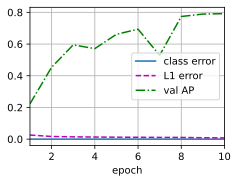

In [108]:
import torch
import torch.nn.functional as F
from object_detection_utils import *
from d2l import torch as d2l

matcher = HungarianMatcher()
optimizer = torch.optim.AdamW(model_det.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.1)
print("total num of parameters in the model:", sum(p.numel() for p in model_det.parameters()))

timer = d2l.Timer()
animator = d2l.Animator(xlabel='epoch', xlim=[1, 10], legend=['class error', 'L1 error', 'val AP'])

ap_calculator = APCalculator(val_loader)

for epoch in range(10):
    metric = d2l.Accumulator(4)
    model_det.train()
    for img, targets in train_loader:
        timer.start()

        img = img.to(device)

        new_targets = []
        for i in range(targets["labels"].shape[0]):
            labels = targets["labels"][i]
            boxes = targets["boxes"][i]
            new_targets.append({
                "labels": labels[labels != -1].to(device),
                "boxes": boxes[labels != -1].to(device)
            })

        outputs = model_det(img)

        num_boxes = sum(len(t["labels"]) for t in new_targets)
        num_boxes = torch.as_tensor([num_boxes], dtype=torch.float, device=next(iter(outputs.values())).device)

        src_logits = outputs["pred_logits"]
        src_boxes = outputs["pred_boxes"]
        src_objectness = outputs["pred_objectness"]

        indices = matcher(outputs, new_targets)
        idx = get_src_permutation_idx(indices)

        target_classes_o = torch.cat([t["labels"][J] for t, (_, J) in zip(new_targets, indices)])
        target_classes = torch.full(src_logits.shape[:2], -100, dtype=torch.int64, device=device)
        target_classes[idx] = target_classes_o
        loss_ce = F.cross_entropy(src_logits.transpose(1, 2), target_classes, ignore_index=-100)

        src_boxes = src_boxes[idx]
        target_boxes = torch.cat([t["boxes"][i] for t, (_, i) in zip(new_targets, indices)], dim=0)

        loss_bbox = F.l1_loss(src_boxes, target_boxes, reduction="none")
        loss_bbox = loss_bbox.sum() / num_boxes

        target_objectness = torch.zeros_like(src_objectness, device=device)
        target_objectness[idx] = 1
        loss_objectness = F.mse_loss(src_objectness, target_objectness, reduction="mean")

        loss = loss_ce + loss_bbox + loss_objectness

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        metric.add(
            loss_ce.cpu().detach().numpy(),
            loss_bbox.cpu().detach().numpy()[0],
            loss_objectness.cpu().detach().numpy(),
            img.size()[0],
        )

    scheduler.step()
    cls_err, L1_error, obj_error = metric[0] / metric[3], metric[1] / metric[3], metric[2] / metric[3]
    ap = ap_calculator.calculate_map(model_det, nms_threshold=0.5)
    print(ap)
    animator.add(epoch + 1, (cls_err, L1_error, ap["map_50"]))

print(f"{len(train_loader.dataset) / timer.stop():.1f} examples/sec on {str(device)}")

###Combine detector and classifier
(Following the fine-tuning classif practical)

In [109]:
import os
from PIL import Image
import torch
from torchvision import transforms
from object_detection_utils import predict

classifier_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

def crop_from_cxcywh(pil_img, box, img_size):
    cx, cy, w, h = box.tolist()

    scale_x = pil_img.width / img_size[0]
    scale_y = pil_img.height / img_size[1]

    cx *= scale_x
    cy *= scale_y
    w *= scale_x
    h *= scale_y

    x1 = int(cx - w / 2)
    y1 = int(cy - h / 2)
    x2 = int(cx + w / 2)
    y2 = int(cy + h / 2)

    x1 = max(0, min(x1, pil_img.width - 1))
    y1 = max(0, min(y1, pil_img.height - 1))
    x2 = max(0, min(x2, pil_img.width))
    y2 = max(0, min(y2, pil_img.height))

    if x2 <= x1 or y2 <= y1:
        return None

    return pil_img.crop((x1, y1, x2, y2))


def predict_test_submission_two_step(model_det, model_cls, test_dataset, output_txt_path, img_size=(224, 224)):
    model_det.eval()
    model_cls.eval()
    model_det.to(device)
    model_cls.to(device)

    with open(output_txt_path, "w") as out_file:
        for i in range(len(test_dataset)):
            img_path = test_dataset.img_files[i]
            pil_img = Image.open(img_path).convert("RGB")
            tensor_img = test_dataset.transforms(pil_img).to(device)

            boxes, scores, _ = predict(
                model_det,
                tensor_img,
                n_classes=1,
                nms_threshold=0.5,
                conf_threshold=0.3,
            )

            file_name = os.path.basename(img_path)

            for box, score in zip(boxes, scores):
                crop = crop_from_cxcywh(pil_img, box, img_size)
                if crop is None:
                    continue

                crop_tensor = classifier_transform(crop).unsqueeze(0).to(device)

                with torch.no_grad():
                    cls_logits = model_cls(crop_tensor)
                    pred_class = cls_logits.argmax(dim=1).item() + 1

                cx, cy, w, h = box.tolist()
                cx /= pil_img.width
                cy /= pil_img.height
                w /= pil_img.width
                h /= pil_img.height

                cx = max(0, min(1, cx))
                cy = max(0, min(1, cy))
                w = max(0, min(1, w))
                h = max(0, min(1, h))

                out_file.write(f"{file_name},{cx},{cy},{w},{h},{pred_class},{score.item()}\n")

    print(f"Predictions saved to {output_txt_path}")

###Visualize the results
(This block of code is based on the object detection practical - especially the part (predict and plot_bbox). However, it is extended for the two-step approach)

[predict: gives boxes only
crop each box -> run model_cls -> get label
plot_bbox --> updated labels from cls]

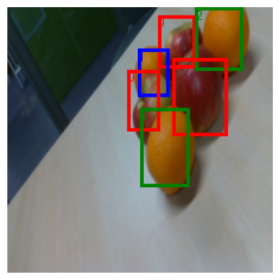

In [121]:
import random
from torchvision.transforms import ToPILImage

idx = random.randint(0, len(test_dataset) - 1)
img = test_dataset[idx]

boxes, scores, _ = predict(
    model_det,
    img.to(device),
    n_classes=1,
    nms_threshold=0.5,
    conf_threshold=0.3,
)

final_boxes = []
final_labels = []

pil_img = ToPILImage()(img)

for box in boxes:
    crop = crop_from_cxcywh(pil_img, box.cpu(), (224, 224))
    if crop is None:
        continue

    cls_input = classifier_transform(crop).unsqueeze(0).to(device)

    with torch.no_grad():
        cls_output = model_cls(cls_input)
        pred_label = cls_output.argmax(dim=1).item()

    final_boxes.append(box.cpu())
    final_labels.append(pred_label)

plot_img = plot_bbox(ToPILImage()(img), final_boxes, final_labels)
plt.imshow(plot_img)
plt.axis("off")
plt.show()

## Creating submission `.txt` file
The submission format should be a txt file as follow where predicted boxes are presented as `image_filename, cx, cy, w, h, class_id, confidence. This is an example:

```
color_001.png, 0.9385692477226257, 0.12406756728887558, 0.15019071102142334, 0.22750574350357056, 3, 0.9989498257637024
color_002.png, 0.699505090713501, 0.38808369636535645, 0.25795409083366394, 0.4329442083835602, 2, 0.9999927282333374
color_002.png, 0.8748611807823181, 0.6965410709381104, 0.15483522415161133, 0.2767787575721741, 3, 0.9996340274810791
color_003.png, 0.5620995163917542, 0.36693891882896423, 0.3271831274032593, 0.43740174174308777, 2, 0.9999911785125732
color_004.png, 0.7048399448394775, 0.5529986619949341, 0.19585376977920532, 0.29669857025146484, 3, 0.9999991655349731
color_004.png, 0.6807190775871277, 0.18781284987926483, 0.18665297329425812, 0.3028806447982788, 3, 0.9999967813491821
color_004.png, 0.8595101237297058, 0.360429972410202, 0.2043967992067337, 0.3125438988208771, 3, 0.9999872446060181
color_005.png, 0.5389502048492432, 0.5513347387313843, 0.18025022745132446, 0.3195890188217163, 3, 0.9999912977218628
color_005.png, 0.5121865272521973, 0.2852896749973297, 0.1954585462808609, 0.274965763092041, 3, 0.9999532699584961
color_006.png, 0.25715094804763794, 0.9217860102653503, 0.17427219450473785, 0.1739407777786255, 2, 0.9999980926513672
````

We provide you some starting code for this in the next cell.


In [110]:
def predict_test_submission_two_step(model_det, model_cls, test_dataset, output_txt_path,
                                     img_size, score_threshold=0.3, nms_threshold=0.3):
    model_det.eval()
    model_cls.eval()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model_det.to(device)
    model_cls.to(device)

    with open(output_txt_path, "w") as out_file:
        for i in range(len(test_dataset)):
            img_path = test_dataset.img_files[i]
            pil_img = Image.open(img_path).convert("RGB")
            tensor_img = test_dataset.transforms(pil_img).to(device)

            boxes, scores, _ = predict(
                model_det,
                tensor_img,
                n_classes=1,
                nms_threshold=nms_threshold,
                conf_threshold=score_threshold
            )

            file_name = os.path.basename(img_path)

            for box, sc in zip(boxes, scores):
                crop = crop_from_cxcywh(pil_img, box.cpu(), (img_size, img_size))
                if crop is None:
                    continue

                cls_input = classifier_transform(crop).unsqueeze(0).to(device)

                with torch.no_grad():
                    cls_output = model_cls(cls_input)
                    pred_label = cls_output.argmax(dim=1)

                box = box / img_size
                cx, cy, w, h = box.tolist()

                cx = max(0, min(1, cx))
                cy = max(0, min(1, cy))
                w = max(0, min(1, w))
                h = max(0, min(1, h))

                out_file.write(
                    f"{file_name},{cx},{cy},{w},{h},{pred_label.item()+1},{sc.item()}\n"
                )

    print(f"Predictions saved to {output_txt_path}")

(Based on object detection day 1 and 2- this is not an exact copy, cause we dont have annotations for the test set, so we created a custom TestDataset)

In [111]:
class TestDataset(torch.utils.data.Dataset):
    def __init__(self, img_folder, transforms=None):
        self.img_folder = img_folder
        self.transforms = transforms

        self.img_files = sorted(
            [os.path.join(img_folder, f) for f in os.listdir(img_folder)
             if f.lower().endswith((".png", ".jpg", ".jpeg"))]
        )

    def __getitem__(self, idx):
        img_path = self.img_files[idx]
        img = Image.open(img_path).convert("RGB")

        if self.transforms:
            img = self.transforms(img)

        return img

    def __len__(self):
        return len(self.img_files)

In [112]:
test_dataset = TestDataset(
    img_folder="fruit-detection-challenge/test",
    transforms=transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])
)

## Testing your code before submitting using the validation set
We provide you with the validation set in the same `.txt` format used in the submission file. Check it here `fruit-detection-challenge/detection/annotations/val.txt`.

We also provide you with the code that the submission server uses to calculate AP performance. You can find it in `object_detection_utils.py` with name `FileBasedAPCalculator`. Let's see how to use it.

Let's first create a noisy version of our ground truth `val.txt` for this demonstration.

In [113]:
import numpy as np

def add_noise_to_box(box_coords, noise_factor=0.1):
    noisy_box = []
    for coord in box_coords:
        noisy_coord = np.random.normal(loc=coord, scale=noise_factor * coord)
        noisy_box.append(max(0, min(noisy_coord, 1)))  # Ensure the values are within [0, 1]
    return noisy_box

def remove_random_predictions(predictions, removal_fraction=0.2):
    num_predictions = len(predictions)
    indices_to_remove = np.random.choice(num_predictions, size=int(removal_fraction * num_predictions), replace=False)
    remaining_predictions = [pred for i, pred in enumerate(predictions) if i not in indices_to_remove]
    return remaining_predictions

def process_predictions(file_path):
    predictions = []
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split(',')
            image_name = parts[0]
            box_coords = list(map(float, parts[1:5]))
            class_id = int(parts[5])
            confidence = 1.0
            predictions.append((image_name, *box_coords, class_id, confidence))

    noisy_predictions = []
    for pred in predictions:
        image_name, x_center, y_center, width, height, class_id, conf = pred
        noisy_box = add_noise_to_box([x_center, y_center, width, height], 0.05)
        noisy_predictions.append((image_name, *noisy_box, class_id, conf))

    remaining_predictions = remove_random_predictions(noisy_predictions, 0.1)

    return remaining_predictions

def save_processed_predictions(predictions, output_file_path):
    with open(output_file_path, 'w') as f:
        for pred in predictions:
            line = ','.join(map(str, pred))
            f.write(line + '\n')



In [114]:
predict_test_submission_two_step(
    model_det,
    model_cls,
    test_dataset,
    "raw_predictions.txt",
    img_size=224
)

processed_predictions = process_predictions("raw_predictions.txt")

save_processed_predictions(
    processed_predictions,
    "submission_two_step_noisy.txt"
)

Predictions saved to raw_predictions.txt
